To perform the homework for Module 2, I need to set up the environment using `uv` and use the provided helper scripts to manage the ONNX embedding model. Below is the step-by-step approach.

Setup
Follow these steps to initialize your project:

In [ ]:
mkdir 02-vector-search && cd 02-vector-search
uv init --no-workspace
uv add onnxruntime tokenizers numpy tqdm minsearch gitsource
uv add --dev huggingface-hub jupyter

# Download helper scripts
PREFIX=https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/main/02-vector-search/embed
wget $PREFIX/download.py
wget $PREFIX/embedder.py

# Download the model
uv run python download.py

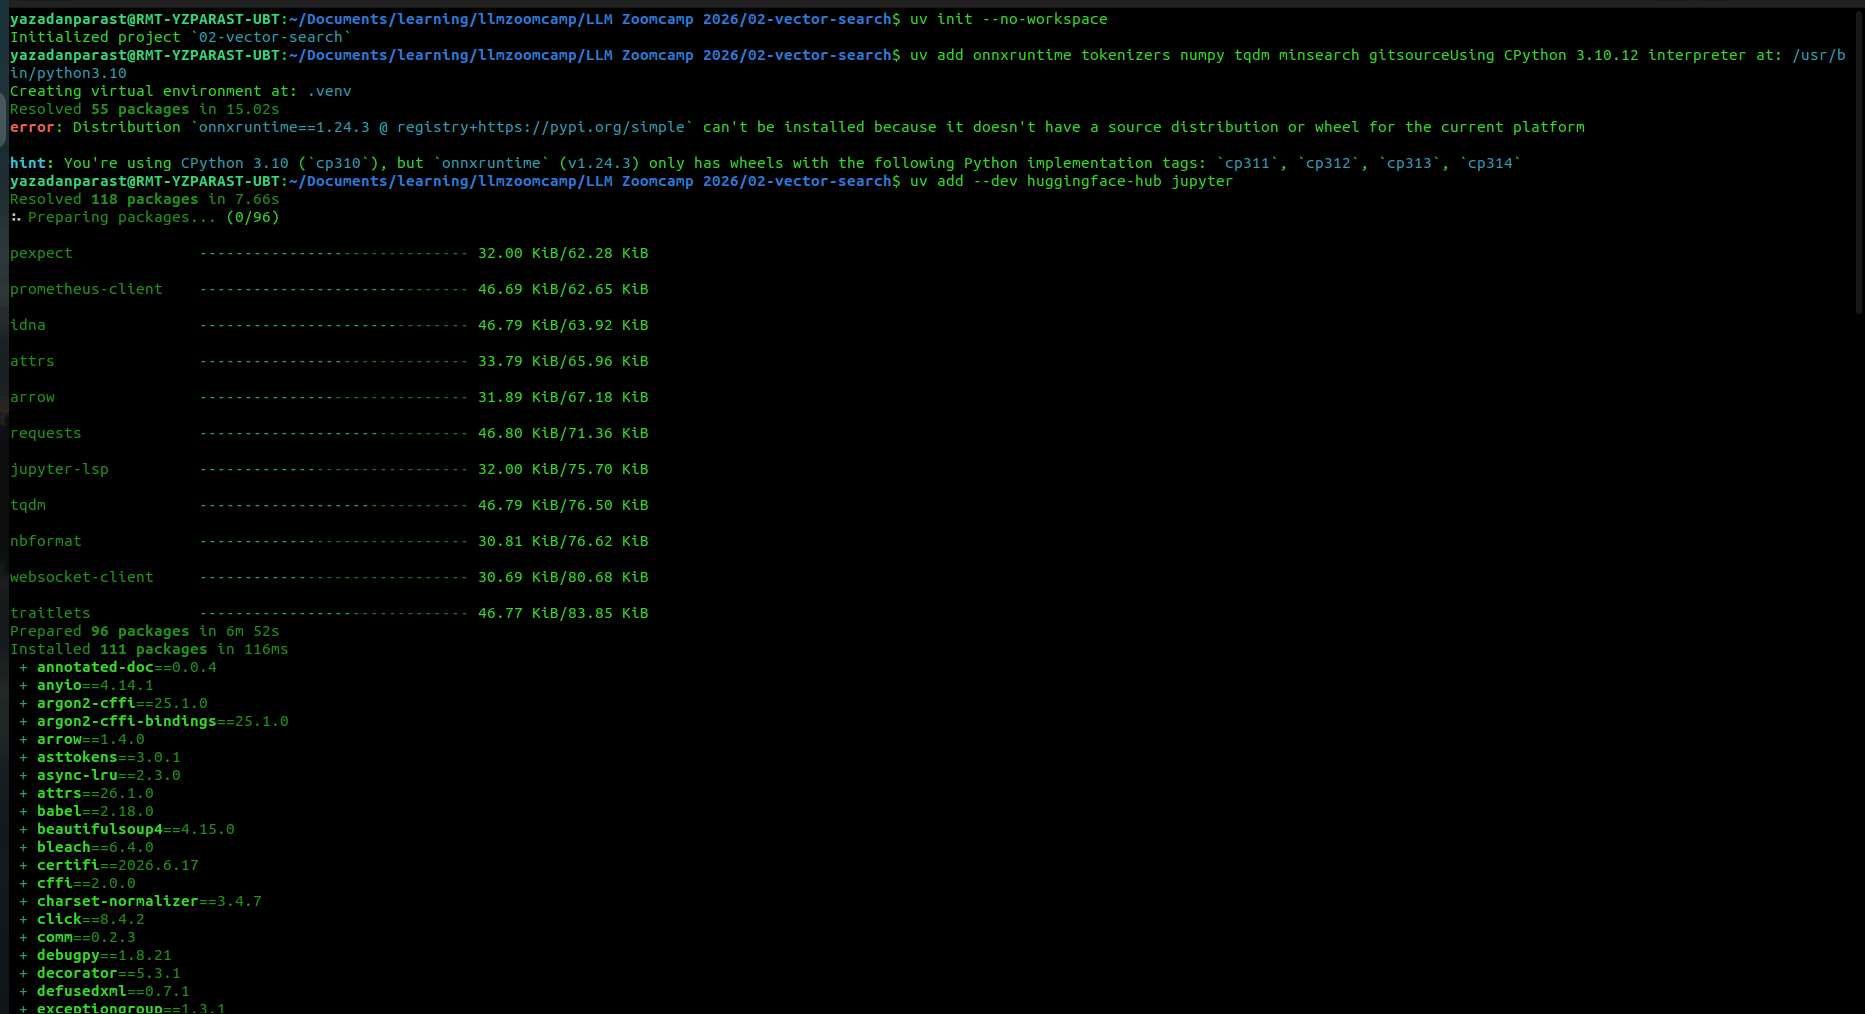

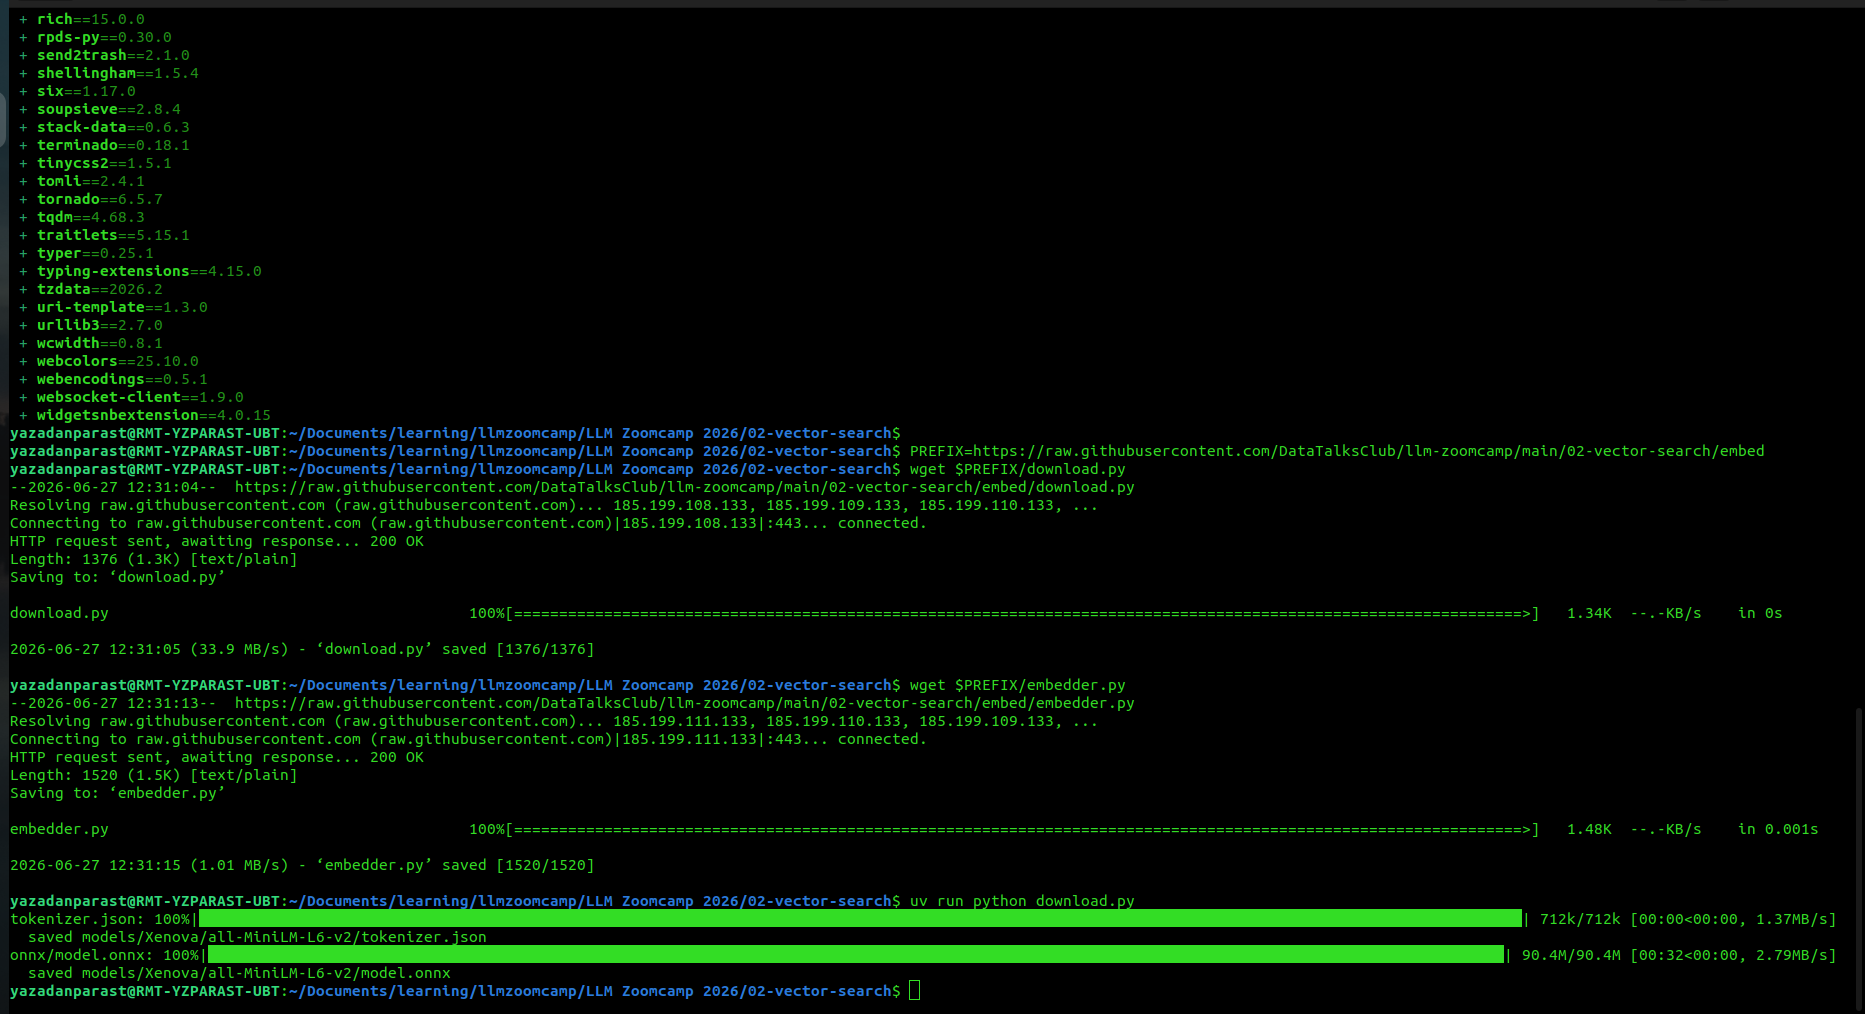

Q1. Embedding a Query

You can use the `Embedder` class to embed your query and check the first element of the resulting 384-dimensional vector.

In [1]:
from embedder import Embedder
model = Embedder()
v = model.encode("How does approximate nearest neighbor search work?")
print(v[0])

-0.02058200593003704


Q2. Cosine Similarity

Load your data and calculate the similarity between the query vector and the document vector.

### Method1: Using Local File

In [2]:
# 1. Open and read the file
# Ensure the path matches where you have the lesson files stored
file_path = "./07-sqlitesearch-vector.md"

with open(file_path, "r", encoding="utf-8") as f:
    doc_content = f.read()

# 2. Use your initialized embedder to encode the content
# (Assuming 'model' is your instance of the Embedder class)
v_doc = model.encode(doc_content)

# 3. Compute cosine similarity with the query vector (v) from Q1
# Since the ONNX embedder returns normalized vectors, dot product = cosine similarity
similarity = v_doc.dot(v)

print(f"Cosine similarity: {similarity}")

Cosine similarity: 0.3610702814461231


### Method 2: Using GithubRepositoryDataReader


In [3]:

# 1. Open repo and read the file
from gitsource import GithubRepositoryDataReader

# Configure the reader to fetch only the markdown files from the lessons folder
reader = GithubRepositoryDataReader(
    repo_owner="DataTalksClub",
    repo_name="llm-zoomcamp",
    commit_id="8c1834d", # The exact commit mentioned in the homework
    allowed_extensions={"md"},
    filename_filter=lambda path: "/lessons/" in path,
)

# This downloads and parses all 72 files into a list of dictionaries
documents = [file.parse() for file in reader.read()]

# Now, to get the content of your specific file:
target_filename = "02-vector-search/lessons/07-sqlitesearch-vector.md"
doc = next(d for d in documents if d['filename'] == target_filename)

doc_content = doc['content']
print(doc_content[:500]) # Prints the first 500 characters to verify content

# Vector Search with sqlitesearch

Video: [Watch this lesson](https://www.youtube.com/watch?v=csxKescwJYM&list=PL3MmuxUbc_hLZFNgSad56pDBKK8KO0XIv)

In the previous section we used minsearch for vector search.

It works, but it has three problems:

- It rebuilds the index on every startup
- It keeps everything in memory
- It searches by brute force


With text search we never felt these. Indexing was fast because we
didn't embed anything. With vector search, indexing runs a neural
network over ev


In [4]:
# 2. Use your initialized embedder to encode the content
# (Assuming 'model' is your instance of the Embedder class)
v_doc = model.encode(doc_content)

# 3. Compute cosine similarity with the query vector (v) from Q1
# Since the ONNX embedder returns normalized vectors, dot product = cosine similarity
similarity = v_doc.dot(v)

print(f"Cosine similarity: {similarity}")

Cosine similarity: 0.3610702814461231


Q3. Chunking and Search by Hand

Chunking splits large pages into smaller segments to maintain semantic focus.

In [5]:
from gitsource import chunk_documents
chunks = chunk_documents(documents, size=2000, step=1000)
# Embed all chunks
X = model.encode_batch([c['content'] for c in chunks])
scores = X.dot(v)
# Find the highest scoring chunk
best_idx = scores.argmax()
print(chunks[best_idx]['filename'])

02-vector-search/lessons/07-sqlitesearch-vector.md


Q4. Vector Search with Minsearch

Use `minsearch` for a cleaner search implementation.

### Method1

Step 1. Import everything

In [19]:
from gitsource import GithubRepositoryDataReader
from gitsource import chunk_documents

from embedder import Embedder
from minsearch import VectorSearch

import numpy as np

Step 2. Load the embedding model

In [20]:
embedder = Embedder()

Step 3. Read the GitHub repository

In [21]:
reader = GithubRepositoryDataReader(
    repo_owner="DataTalksClub",
    repo_name="llm-zoomcamp",
    commit_id="8c1834d",
    allowed_extensions={"md"},
    filename_filter=lambda path: "/lessons/" in path,
)

documents = [file.parse() for file in reader.read()]

In [24]:
len(documents)

72

Step 4. Chunk the documents

In [25]:
chunks = chunk_documents(
    documents,
    size=2000,
    step=1000
)

In [26]:
len(chunks)

295

Step 5. Embed every chunk

In [27]:
texts = [chunk["content"] for chunk in chunks]

X = embedder.encode_batch(texts)

In [28]:
print(X.shape)

(295, 384)


Step 6. Build the VectorSearch index

In [29]:
vindex = VectorSearch(
    keyword_fields=["filename"]
)

In [30]:
vindex.fit(X, chunks)

Step 7. Create the query embedding

In [31]:
query = "What metric do we use to evaluate a search engine?"

query_vector = embedder.encode(query)

Step 8. Perform vector search

In [32]:
results = vindex.search(
    query_vector,
    num_results=5
)

Step 9. Print the results

In [33]:
for r in results:
    print(r["filename"])

04-evaluation/lessons/05-search-metrics.md
04-evaluation/lessons/01-intro.md
01-agentic-rag/lessons/05-search.md
04-evaluation/lessons/01-intro.md
04-evaluation/lessons/15-next-steps.md


Step 10. Print only the first answer

In [34]:
print(results[0]["filename"])

04-evaluation/lessons/05-search-metrics.md


-----------------------------------------------------------------------------------


### Method2

In [6]:
from minsearch import VectorSearch
vindex = VectorSearch(keyword_fields=["filename"])
vindex.fit(X, chunks)
results = vindex.search(v, num_results=5)
print(results[0]['filename'])

02-vector-search/lessons/07-sqlitesearch-vector.md


In [12]:
# Check if your chunks contain the file you expect
filenames = [c['filename'] for c in chunks]
if "04-evaluation/lessons/05-search-metrics.md" not in filenames:
    print("Warning: The target file is missing from your chunks list!")

In [16]:
# Check if the target file is in your list of chunks
target = "04-evaluation/lessons/05-search-metrics.md"
found = [c for c in chunks if target in c['filename']]

if found:
    print(f"File found! Number of chunks for this file: {len(found)}")
else:
    print("File not found in chunks! You may need to update your data ingestion.")

File found! Number of chunks for this file: 5


In [13]:
# Re-encode the query specifically for Q4
query = "What metric do we use to evaluate a search engine?"
v = model.encode(query) 

# Perform the search
results = vindex.search(v, num_results=5)
print(results[0]['filename'])

04-evaluation/lessons/05-search-metrics.md


Q5. Text Search vs. Vector Search

By comparing these, you identify which documents are found via meaning (vector) but missed by exact word matching (text).

In [7]:
# Vector search
vec_results = vindex.search(model.encode("How do I store vectors in PostgreSQL?"), num_results=5)
# Keyword search (using a standard Index)
from minsearch import Index
index = Index(text_fields=["content"], keyword_fields=["filename"])
index.fit(chunks)
text_results = index.search("How do I store vectors in PostgreSQL?", num_results=5)

In [8]:
text_results

[{'start': 4000,
  'content': 'get 0.01.\n\nThe first score for `q1` vs `d` (0.32) is higher, so that query is more\nsimilar to the document about registration. The second score for `q2`\nvs `d` sits near 0, because installing Docker has nothing to do with\nregistration. A score near 0 means the two vectors are about as\ndifferent as they can be.\n\nThat\'s the whole idea behind vector search: similar texts get similar\nvectors, and a dot product tells us how similar.\n\n## Cosine similarity\n\nThe `all-MiniLM-L6-v2` model outputs normalized vectors - vectors with\nunit length. When both vectors are normalized, the dot product equals\ncosine similarity. That\'s why the model documentation says it "uses\ncosine similarity."\n\nCosine similarity measures the angle between two vectors, ignoring\ntheir length:\n\n- 1.0 = same direction (similar)\n- 0.0 = perpendicular (unrelated)\n- -1.0 = opposite direction (opposite meaning)\n\nFormally, if `theta` is the angle between two vectors, cosin

In [9]:
text_results[0]['filename']


'02-vector-search/lessons/02-embeddings.md'

In [10]:
text_results[0]['content'][:500]  # Print the first 500 characters of the content

"get 0.01.\n\nThe first score for `q1` vs `d` (0.32) is higher, so that query is more\nsimilar to the document about registration. The second score for `q2`\nvs `d` sits near 0, because installing Docker has nothing to do with\nregistration. A score near 0 means the two vectors are about as\ndifferent as they can be.\n\nThat's the whole idea behind vector search: similar texts get similar\nvectors, and a dot product tells us how similar.\n\n## Cosine similarity\n\nThe `all-MiniLM-L6-v2` model outputs normaliz"

Q6. Hybrid Search (RRF)

Use the provided RRF function to merge rankings.

### Method1

In [ ]:
def rrf(result_lists, k=60, num_results=5):
    scores = {}
    docs = {}

    for results in result_lists:
        for rank, doc in enumerate(results):
            key = (doc["filename"], doc["start"])
            scores[key] = scores.get(key, 0) + 1 / (k + rank)
            docs[key] = doc

    ranked = sorted(scores, key=scores.get, reverse=True)
    return [docs[key] for key in ranked[:num_results]]
                
    # Sort documents by their RRF score in descending order
    reranked = sorted(
        [
            {**rrf_scores[f"{doc_id}_obj"], "score": score} 
            for doc_id, score in rrf_scores.items() 
            if not doc_id.endswith("_obj")
        ],
        key=lambda x: x["score"],
        reverse=True
    )
    
    return reranked


# Assuming you have already initialized your indices as 'vindex' and 'index'
query = "How do I give the model access to tools?"

# Generate the vector search results (uses the embedding model)
query_vector = model.encode(query)
vector_results = vindex.search(query_vector, num_results=5)

# Generate the text search results (uses the keyword index)
text_results = index.search(query, num_results=5)

# Now we can call the rrf function with the vector and text search results:
results = rrf([vector_results, text_results])
print(results[0]['filename'])

01-agentic-rag/lessons/13-function-calling.md


### Method2

In [18]:
def rrf(result_lists, k=60):
    # Create a dictionary to store the final ranking score for each document
    rrf_scores = {}
    
    # Process each search result list
    for results in result_lists:
        for rank, doc in enumerate(results):
            doc_id = doc['filename'] # Or use 'id' if your documents have one
            
            # RRF formula: sum of 1 / (k + rank)
            # We add 1 to rank because enumerate starts at 0
            if doc_id not in rrf_scores:
                rrf_scores[doc_id] = 0
            rrf_scores[doc_id] += 1 / (k + rank + 1)
            
            # Keep a reference to the actual document object
            if 'doc_obj' not in rrf_scores:
                rrf_scores[f"{doc_id}_obj"] = doc

    # Sort documents by their RRF score in descending order
    reranked = sorted(
        [
            {**rrf_scores[f"{doc_id}_obj"], "score": score} 
            for doc_id, score in rrf_scores.items() 
            if not doc_id.endswith("_obj")
        ],
        key=lambda x: x["score"],
        reverse=True
    )
    
    return reranked


# Assuming you have already initialized your indices as 'vindex' and 'index'
query = "How do I give the model access to tools?"

# Generate the vector search results (uses the embedding model)
query_vector = model.encode(query)
vector_results = vindex.search(query_vector, num_results=5)

# Generate the text search results (uses the keyword index)
text_results = index.search(query, num_results=5)

# Now we can call the rrf function with the vector and text search results:
results = rrf([vector_results, text_results])
print(results[0]['filename'])

01-agentic-rag/lessons/13-function-calling.md
